In [2]:
pip install pandas numpy matplotlib seaborn pytz

Note: you may need to restart the kernel to use updated packages.


In [3]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from datetime import datetime
from zoneinfo import ZoneInfo

import warnings
warnings.filterwarnings("ignore")

In [4]:
#Loading dataset
df = pd.read_csv("C:/Users/yashr/Desktop/eve3/google_play_store_dataset.csv")

In [5]:
print(df.columns)
print(df.shape)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')
(10841, 13)


In [6]:
#cleaning install columns
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(
    df["Installs"],
    errors="coerce"
)

In [7]:
#cleaning reviews column
df["Reviews"] = pd.to_numeric(
    df["Reviews"],
    errors="coerce"
)

In [8]:
##remobing invalid rows
df = df.dropna(
    subset=[
        "App",
        "Category",
        "Installs",
        "Reviews"
    ]
)

In [9]:
#creating historical data 
months = pd.date_range(
    start="2023-01-01",
    periods=24,
    freq="MS"
)

In [10]:
historical_rows = []

for _, row in df.iterrows():

    app = row["App"]
    category = row["Category"]
    reviews = row["Reviews"]

    target_installs = int(row["Installs"])

    starting_installs = max(
        int(target_installs * 0.20),
        100
    )

    current = starting_installs

    for month in months:

        growth = np.random.uniform(
            0.03,
            0.12
        )

        if np.random.random() < 0.20:
            growth = np.random.uniform(
                0.21,
                0.45
            )

        current = int(
            current * (1 + growth)
        )

        historical_rows.append([
            month,
            app,
            category,
            current,
            reviews
        ])

In [11]:
history_df = pd.DataFrame(
    historical_rows,
    columns=[
        "month",
        "app_name",
        "app_category",
        "installs",
        "reviews"
    ]
)

print(history_df.shape)

(260160, 5)


In [12]:
#Applying review filters
filtered = history_df[
    history_df["reviews"] > 500
].copy()

In [13]:
#Remov Apps Starting With X/Y/Z
filtered = filtered[
    ~filtered["app_name"].str.startswith(
        (
            "X","Y","Z",
            "x","y","z"
        ),
        na=False
    )
]

In [14]:
#removing app containing s
filtered = filtered[
    ~filtered["app_name"].str.contains(
        "s",
        case=False,
        na=False
    )
]

In [15]:
#Category Filter
filtered = filtered[
    filtered["app_category"]
    .str.startswith(
        ("B","C","E"),
        na=False
    )
]

In [16]:
#translating categories
translation_map = {

    "Beauty":
        "सौंदर्य",

    "Business":
        "வணிகம்",

    "Dating":
        "Partnersuche"
}

In [17]:
filtered["display_category"] = (
    filtered["app_category"]
    .replace(translation_map)
)

In [18]:
#Aggregating monthy installs
monthly = (
    filtered
    .groupby(
        [
            "month",
            "display_category"
        ]
    )["installs"]
    .sum()
    .reset_index()
)

In [19]:
monthly = monthly.sort_values(
    [
        "display_category",
        "month"
    ]
)

In [20]:
monthly["mom_growth"] = (
    monthly
    .groupby(
        "display_category"
    )["installs"]
    .pct_change()
)

In [21]:
#Identify Significant Growth
monthly["significant_growth"] = (
    monthly["mom_growth"] > 0.20
)

In [22]:
monthly.head()

,month,display_category,installs,mom_growth,significant_growth
0,2023-01-01,BEAUTY,455135,NaN,False
8,2023-02-01,BEAUTY,493221,0.083681,False
16,2023-03-01,BEAUTY,544018,0.102990,False
24,2023-04-01,BEAUTY,597186,0.097732,False
32,2023-05-01,BEAUTY,648889,0.086578,False


In [26]:
# time restrictions
ist_now = datetime.now(
    ZoneInfo("Asia/Kolkata")
)

show_graph = True

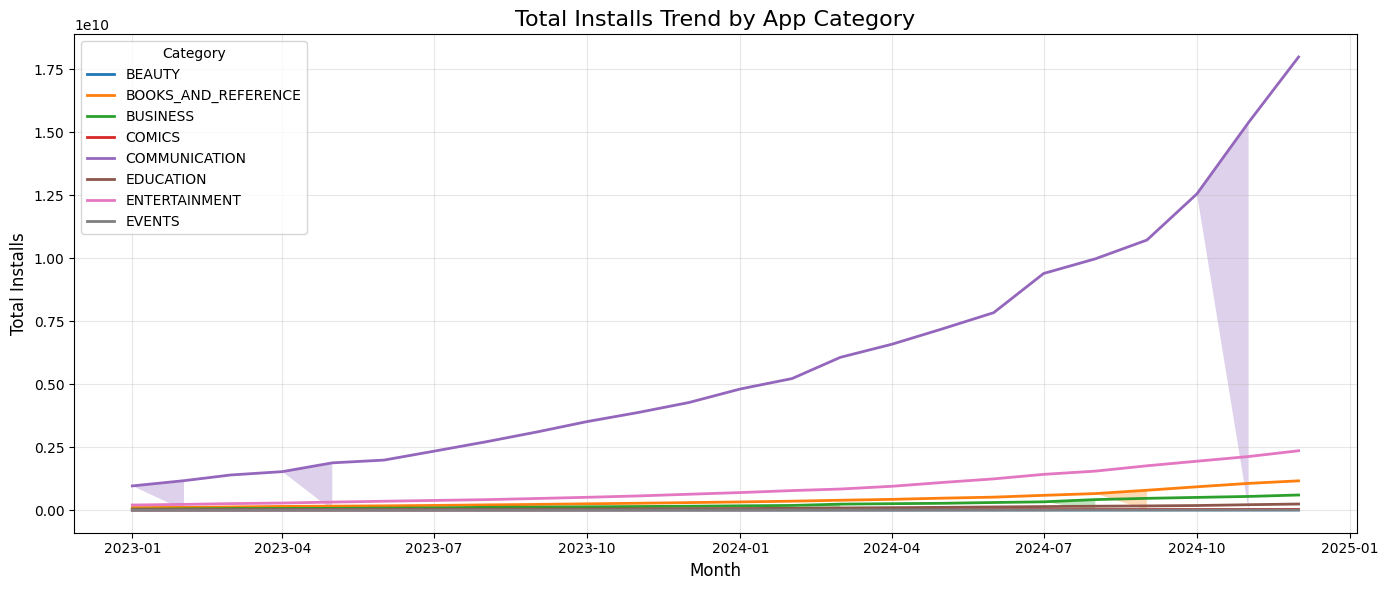

In [28]:
#Plotting line chart
if show_graph:

    plt.figure(
        figsize=(14,6)
    )

    categories = (
        monthly[
            "display_category"
        ]
        .unique()
    )

    for category in categories:

        cat_data = monthly[
            monthly[
                "display_category"
            ] == category
        ]

        plt.plot(
            cat_data["month"],
            cat_data["installs"],
            label=category,
            linewidth=2
        )

        plt.fill_between(
            cat_data["month"],
            cat_data["installs"],
            where=cat_data[
                "significant_growth"
            ],
            alpha=0.30,
            interpolate=True
        )

    plt.title(
        "Total Installs Trend by App Category",
        fontsize=16
    )

    plt.xlabel(
        "Month",
        fontsize=12
    )

    plt.ylabel(
        "Total Installs",
        fontsize=12
    )

    plt.legend(
        title="Category"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

else:

    print(
        "Graph hidden. Available only between 6 PM and 9 PM IST."
    )

In [25]:
print(filtered.shape)

print(
    monthly[
        "display_category"
    ]
    .value_counts()
)

(5880, 6)
display_category
BEAUTY                 24
BOOKS_AND_REFERENCE    24
BUSINESS               24
COMICS                 24
COMMUNICATION          24
EDUCATION              24
ENTERTAINMENT          24
EVENTS                 24
Name: count, dtype: int64
